АНАЛИЗ ПОКУПОК С ПОМОЩЬЮ FP-GROWTH
Транзакции:
1: ['shrimp', 'almonds', 'avocado', 'vegetables mix', 'green grapes', 'whole weat flour', 'yams', 'cottage cheese', 'energy drink', 'tomato juice', 'low fat yogurt', 'green tea', 'honey', 'salad', 'mineral water', 'salmon', 'antioxydant juice', 'frozen smoothie', 'spinach', 'olive oil']
2: ['burgers', 'meatballs', 'eggs']
3: ['chutney']
4: ['turkey', 'avocado']
5: ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea']
6: ['low fat yogurt']
7: ['whole wheat pasta', 'french fries']
8: ['soup', 'light cream', 'shallot']
9: ['frozen vegetables', 'spaghetti', 'green tea']
10: ['french fries']
11: ['eggs', 'pet food']
12: ['cookies']
13: ['turkey', 'burgers', 'mineral water', 'eggs', 'cooking oil']
14: ['spaghetti', 'champagne', 'cookies']
15: ['mineral water', 'salmon']
16: ['mineral water']
17: ['shrimp', 'chocolate', 'chicken', 'honey', 'oil', 'cooking oil', 'low fat yogurt']
18: ['turkey', 'eggs']
19: ['turkey', 'fresh tuna

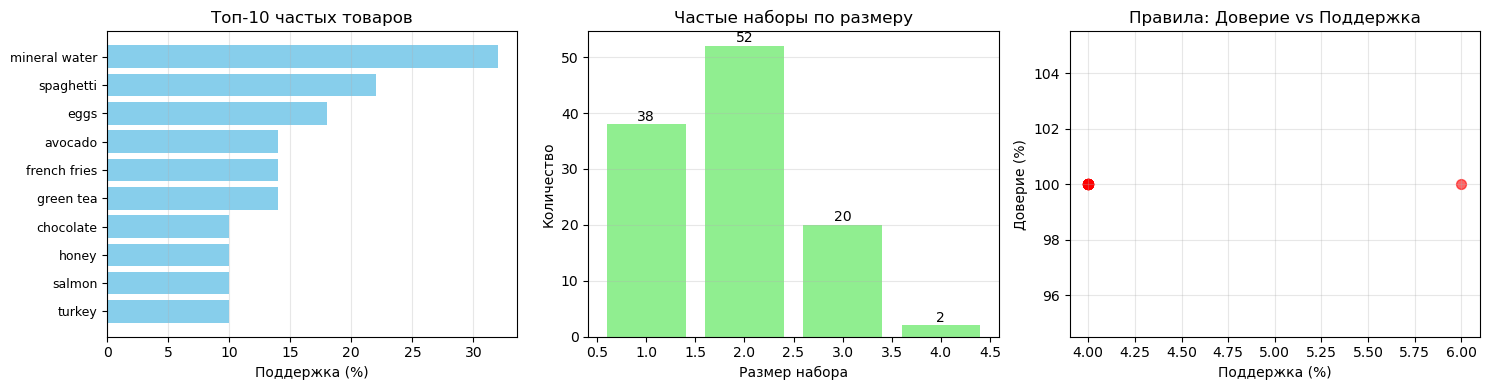


СОХРАНЕНИЕ РЕЗУЛЬТАТОВ
✓ Результаты сохранены в frequent_itemsets_fp.csv и association_rules_fp.csv

АНАЛИЗ ЗАВЕРШЕН!


In [19]:
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import csv
from itertools import combinations

# ==============================================
# 1. FP-GROWTH АЛГОРИТМ
# ==============================================

class FPTreeNode:
    def __init__(self, item, count, parent):
        self.item = item
        self.count = count
        self.parent = parent
        self.children = {}
        self.link = None

def build_fp_tree(transactions, min_support_count):
    """Строит FP-дерево"""
    item_counts = Counter()
    for transaction in transactions:
        for item in transaction:
            item_counts[item] += 1
    
    frequent_items = {item: count for item, count in item_counts.items() 
                     if count >= min_support_count}
    
    if not frequent_items:
        return None, None, None
    
    sorted_items = sorted(frequent_items.items(), key=lambda x: (-x[1], x[0]))
    header_table = {}
    for item, count in sorted_items:
        header_table[item] = [count, None]
    
    root = FPTreeNode(None, 0, None)
    
    for transaction in transactions:
        filtered = [item for item in transaction if item in frequent_items]
        if not filtered:
            continue
            
        filtered.sort(key=lambda x: (-frequent_items[x], x))
        current = root
        
        for item in filtered:
            if item in current.children:
                child = current.children[item]
                child.count += 1
            else:
                child = FPTreeNode(item, 1, current)
                current.children[item] = child
                
                if header_table[item][1] is None:
                    header_table[item][1] = child
                else:
                    node = header_table[item][1]
                    while node.link is not None:
                        node = node.link
                    node.link = child
            
            current = child
    
    return root, header_table, frequent_items

def ascend_tree(node):
    """Поднимается от узла к корню"""
    path = []
    while node.parent is not None:
        path.append(node.item)
        node = node.parent
    return path[::-1]

def find_prefix_paths(item, header_table):
    """Находит все префиксные пути для товара"""
    paths = []
    node = header_table[item][1]
    
    while node is not None:
        if node.count > 0:
            prefix_path = ascend_tree(node.parent)
            if prefix_path:
                paths.append((prefix_path, node.count))
        node = node.link
    
    return paths

def mine_fp_tree(header_table, min_support_count, prefix, 
                 frequent_itemsets, total_transactions, item_counts):
    """Рекурсивная добыча частых наборов"""
    if not header_table:
        return
    
    items = sorted(header_table.keys(), key=lambda x: header_table[x][0])
    
    for item in items:
        new_set = prefix + [item]
        new_set_tuple = tuple(sorted(new_set))
        support = header_table[item][0] / total_transactions
        
        k = len(new_set_tuple)
        if k not in frequent_itemsets:
            frequent_itemsets[k] = {}
        frequent_itemsets[k][new_set_tuple] = support
        
        conditional_patterns = find_prefix_paths(item, header_table)
        
        if conditional_patterns:
            conditional_counts = Counter()
            for pattern, count in conditional_patterns:
                for pattern_item in pattern:
                    conditional_counts[pattern_item] += count
            
            conditional_frequent = {item: count for item, count in conditional_counts.items()
                                  if count >= min_support_count}
            
            if conditional_frequent:
                conditional_transactions = []
                for pattern, count in conditional_patterns:
                    filtered_pattern = [p for p in pattern if p in conditional_frequent]
                    if filtered_pattern:
                        conditional_transactions.extend([filtered_pattern] * count)
                
                if conditional_transactions:
                    _, cond_header, _ = build_fp_tree(conditional_transactions, min_support_count)
                    if cond_header:
                        mine_fp_tree(cond_header, min_support_count, new_set,
                                   frequent_itemsets, total_transactions, conditional_frequent)

def fp_growth(transactions, min_support=0.1):
    """Основная функция FP-Growth"""
    if not transactions:
        return {}
    
    total_transactions = len(transactions)
    min_support_count = max(1, int(min_support * total_transactions))
    
    root, header_table, frequent_items = build_fp_tree(transactions, min_support_count)
    
    if root is None:
        return {1: {}}
    
    frequent_itemsets = {}
    prefix = []
    
    if frequent_items:
        frequent_itemsets[1] = {}
        for item, count in sorted(frequent_items.items()):
            support = count / total_transactions
            if support >= min_support:
                frequent_itemsets[1][(item,)] = support
    
    mine_fp_tree(header_table, min_support_count, prefix, 
                frequent_itemsets, total_transactions, frequent_items)
    
    result = {}
    for k in sorted(frequent_itemsets.keys()):
        if frequent_itemsets[k]:
            filtered = {itemset: support for itemset, support in frequent_itemsets[k].items()
                       if support >= min_support}
            if filtered:
                sorted_items = sorted(filtered.items(), key=lambda x: (-x[1], x[0]))
                result[k] = dict(sorted_items)
    
    return result

# ==============================================
# 2. ГЕНЕРАЦИЯ ПРАВИЛ
# ==============================================

def calculate_support(itemset, transactions):
    """Рассчитывает поддержку для itemset"""
    count = 0
    itemset_set = set(itemset)
    for transaction in transactions:
        if itemset_set.issubset(set(transaction)):
            count += 1
    return count / len(transactions)

def generate_rules(frequent_items, transactions, min_confidence=0.7):
    """Генерирует правила ассоциации"""
    rules = []
    
    if not frequent_items:
        return rules
    
    support_lookup = {}
    for size_dict in frequent_items.values():
        support_lookup.update(size_dict)
    
    for k in list(frequent_items.keys()):
        if k < 2:
            continue
        
        for itemset, support_full in frequent_items[k].items():
            itemset_list = list(itemset)
            
            for r in range(1, k):
                for antecedent_idx in combinations(range(k), r):
                    antecedent = tuple(sorted([itemset_list[i] for i in antecedent_idx]))
                    consequent_idx = [i for i in range(k) if i not in antecedent_idx]
                    consequent = tuple(sorted([itemset_list[i] for i in consequent_idx]))
                    
                    support_antecedent = support_lookup.get(
                        antecedent,
                        calculate_support(antecedent, transactions)
                    )
                    
                    if support_antecedent > 0:
                        confidence = support_full / support_antecedent
                    else:
                        confidence = 0
                    
                    if confidence >= min_confidence:
                        support_consequent = support_lookup.get(
                            consequent,
                            calculate_support(consequent, transactions)
                        )
                        
                        lift = confidence / support_consequent if support_consequent > 0 else 0
                        
                        rules.append({
                            'antecedent': set(antecedent),
                            'consequent': set(consequent),
                            'support': support_full,
                            'confidence': confidence,
                            'lift': lift
                        })
    
    rules.sort(key=lambda x: (-x['confidence'], -x['support']))
    return rules

# ==============================================
# 3. ЗАГРУЗКА ДАННЫХ (ВАШИ ДАННЫЕ О ПРОДУКТАХ)
# ==============================================

def load_data():
    """Загружает ваши данные о покупках"""
    data = [
        ['shrimp', 'almonds', 'avocado', 'vegetables mix', 'green grapes', 
         'whole weat flour', 'yams', 'cottage cheese', 'energy drink', 'tomato juice',
         'low fat yogurt', 'green tea', 'honey', 'salad', 'mineral water', 'salmon',
         'antioxydant juice', 'frozen smoothie', 'spinach', 'olive oil'],
        ['burgers', 'meatballs', 'eggs'],
        ['chutney'],
        ['turkey', 'avocado'],
        ['mineral water', 'milk', 'energy bar', 'whole wheat rice', 'green tea'],
        ['low fat yogurt'],
        ['whole wheat pasta', 'french fries'],
        ['soup', 'light cream', 'shallot'],
        ['frozen vegetables', 'spaghetti', 'green tea'],
        ['french fries'],
        ['eggs', 'pet food'],
        ['cookies'],
        ['turkey', 'burgers', 'mineral water', 'eggs', 'cooking oil'],
        ['spaghetti', 'champagne', 'cookies'],
        ['mineral water', 'salmon'],
        ['mineral water'],
        ['shrimp', 'chocolate', 'chicken', 'honey', 'oil', 'cooking oil', 'low fat yogurt'],
        ['turkey', 'eggs'],
        ['turkey', 'fresh tuna', 'tomatoes', 'spaghetti', 'mineral water', 
         'black tea', 'salmon', 'eggs', 'chicken', 'extra dark chocolate'],
        ['meatballs', 'milk', 'honey', 'french fries', 'protein bar'],
        ['red wine', 'shrimp', 'pasta', 'pepper', 'eggs', 'chocolate', 'shampoo'],
        ['rice', 'sparkling water'],
        ['spaghetti', 'mineral water', 'ham', 'body spray', 'pancakes', 'green tea'],
        ['burgers', 'grated cheese', 'shrimp', 'pasta', 'avocado', 
         'honey', 'white wine', 'toothpaste'],
        ['eggs'],
        ['parmesan cheese', 'spaghetti', 'soup', 'avocado', 'milk', 'fresh bread'],
        ['ground beef', 'spaghetti', 'mineral water', 'milk', 'energy bar', 
         'black tea', 'salmon', 'frozen smoothie', 'escalope'],
        ['sparkling water'],
        ['mineral water', 'eggs', 'chicken', 'chocolate', 'french fries'],
        ['frozen vegetables', 'spaghetti', 'yams', 'mineral water'],
        ['herb & pepper', 'tomato sauce', 'light cream', 'magazines'],
        ['mineral water', 'chocolate', 'avocado', 'eggs'],
        ['turkey', 'french fries', 'strawberries'],
        ['frozen vegetables', 'strong cheese', 'chocolate'],
        ['cookies'],
        ['pickles', 'spaghetti', 'salmon', 'escalope'],
        ['energy bar', 'french fries'],
        ['red wine', 'ground beef', 'mineral water'],
        ['mineral water', 'cake', 'cottage cheese'],
        ['pickles', 'champagne', 'green tea'],
        ['spaghetti'],
        ['fresh tuna', 'frozen vegetables', 'spaghetti', 'mineral water', 
         'honey', 'whole wheat rice', 'frozen smoothie', 'escalope'],
        ['spaghetti'],
        ['soup', 'meatballs', 'hot dogs', 'sparkling water'],
        ['escalope'],
        ['soup', 'avocado', 'french fries', 'hot dogs', 
         'brownies', 'body spray', 'pancakes', 'green tea'],
        ['mineral water', 'chicken', 'cereals', 'clothes accessories'],
        ['mineral water', 'bug spray'],
        ['avocado', 'muffins'],
        ['burgers', 'black tea', 'green tea']
    ]
    
    print("Транзакции:")
    for i, t in enumerate(data, 1):
        print(f"{i}: {t}")
    
    print()
    return data


def print_frequent_itemsets(frequent_items):
    """Выводит частые наборы в формате Apriori"""
    print("\n" + "=" * 50)
    print("ЗАПУСК FP-GROWTH")
    print("=" * 50)
    
    for k in sorted(frequent_items.keys()):
        if frequent_items[k]:
            print(f"\nЧастые наборы из {k} товаров:")
            for itemset, support in frequent_items[k].items():
                itemset_set = set(itemset)
                print(f"  {itemset_set} - поддержка: {support:.2%}")

def print_rules(rules, limit=20):
    """Выводит правила в формате Apriori"""
    print("\n" + "=" * 50)
    print("ГЕНЕРАЦИЯ ПРАВИЛ")
    print("=" * 50)
    
    print(f"\nНайдено правил: {len(rules)}")
    
    for i, rule in enumerate(rules[:limit], 1):
        print(f"\nПравило {i}:")
        print(f"  {rule['antecedent']} → {rule['consequent']}")
        print(f"  Поддержка: {rule['support']:.2%}")
        print(f"  Достоверность: {rule['confidence']:.2%}")
        print(f"  Lift: {rule['lift']:.2f}")

# ==============================================
# 5. ГРАФИКИ
# ==============================================

def plot_results(transactions, frequent_items, rules):
    """Строит графики результатов"""
    if not transactions:
        return
    
    plt.figure(figsize=(15, 4))
    
    # График 1: Топ-10 одиночных товаров
    plt.subplot(1, 3, 1)
    if 1 in frequent_items and frequent_items[1]:
        single_items = list(frequent_items[1].items())
        single_items.sort(key=lambda x: x[1], reverse=True)
        
        items = [item[0][0] for item in single_items[:10]]
        supports = [supp * 100 for _, supp in single_items[:10]]
        
        bars = plt.barh(range(len(items)), supports, color='skyblue')
        plt.yticks(range(len(items)), items, fontsize=9)
        plt.xlabel('Поддержка (%)')
        plt.title('Топ-10 частых товаров')
        plt.gca().invert_yaxis()
        plt.grid(True, alpha=0.3, axis='x')
    
    # График 2: Частые наборы по размеру
    plt.subplot(1, 3, 2)
    sizes = []
    counts = []
    
    for size, itemsets in sorted(frequent_items.items()):
        if itemsets:
            sizes.append(size)
            counts.append(len(itemsets))
    
    if sizes:
        bars = plt.bar(sizes, counts, color='lightgreen')
        plt.xlabel('Размер набора')
        plt.ylabel('Количество')
        plt.title('Частые наборы по размеру')
        plt.grid(True, alpha=0.3, axis='y')
        
        for bar, count in zip(bars, counts):
            plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                    str(count), ha='center', va='bottom')
    
    # График 3: Confidence vs Support
    plt.subplot(1, 3, 3)
    if rules:
        confidences = [r['confidence'] * 100 for r in rules[:20]]
        supports = [r['support'] * 100 for r in rules[:20]]
        
        plt.scatter(supports, confidences, c='red', alpha=0.6, s=50)
        plt.xlabel('Поддержка (%)')
        plt.ylabel('Доверие (%)')
        plt.title('Правила: Доверие vs Поддержка')
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ==============================================
# 6. ОСНОВНАЯ ПРОГРАММА
# ==============================================

def main():
    """Главная функция"""
    print("=" * 50)
    print("АНАЛИЗ ПОКУПОК С ПОМОЩЬЮ FP-GROWTH")
    print("=" * 50)
    
    # 1. Загрузка данных
    transactions = load_data()
    
    # 2. Запуск FP-Growth
    min_support = 0.04  # 15% первый был 0.06 второй 0.05 тоже 16 0.04 20 , 0.07
    frequent_items = fp_growth(transactions, min_support)
    
    # 3. Вывод частых наборов (ФОРМАТ КАК В APRIORI)
    print_frequent_itemsets(frequent_items)
    
    # 4. Генерация правил
    min_confidence = 0.3  # 60%
    rules = generate_rules(frequent_items, transactions, min_confidence)
    
    # 5. Вывод правил (ФОРМАТ КАК В APRIORI)
    print_rules(rules, limit=1000)
    
    # 6. Графики
    print("\n" + "=" * 50)
    print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
    print("=" * 50)
    plot_results(transactions, frequent_items, rules)
    
    # 7. Сохранение результатов
    print("\n" + "=" * 50)
    print("СОХРАНЕНИЕ РЕЗУЛЬТАТОВ")
    print("=" * 50)
    
    with open('frequent_itemsets_fp.csv', 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['Размер', 'Набор товаров', 'Поддержка'])
        
        for size, itemsets in frequent_items.items():
            for itemset, support in itemsets.items():
                items_str = ', '.join(itemset)
                writer.writerow([size, items_str, f"{support:.3f}"])
    
    if rules:
        with open('association_rules_fp.csv', 'w', newline='', encoding='utf-8') as f:
            writer = csv.writer(f)
            writer.writerow(['Антецедент', 'Консеквент', 'Поддержка', 'Доверие', 'Lift'])
            
            for rule in rules:
                ante_str = ', '.join(sorted(rule['antecedent']))
                cons_str = ', '.join(sorted(rule['consequent']))
                
                writer.writerow([
                    ante_str,
                    cons_str,
                    f"{rule['support']:.3f}",
                    f"{rule['confidence']:.3f}",
                    f"{rule['lift']:.3f}"
                ])
    
    print("✓ Результаты сохранены в frequent_itemsets_fp.csv и association_rules_fp.csv")
    print("\n" + "=" * 50)
    print("АНАЛИЗ ЗАВЕРШЕН!")
    print("=" * 50)

# ==============================================
# ЗАПУСК
# ==============================================

if __name__ == "__main__":
    plt.rcParams.update({'font.size': 10})
    
    try:
        main()
    except Exception as e:
        print(f"\nОшибка: {e}")
        print("Программа завершена.")